# Loyiha 1: Normal Equation — sklearn.fit() ichida nima bor — Abalone (UCI)

**Talaba:** student3 · **Modul:** M1 (Chiziqli algebra) + M0 · **Kitob (ML_GUIDE):** 3-bob (Matematik asoslar), 5-bob (Normal Equation vs GD) · **Qiyinlik:** ⭐⭐⭐ · **Taxminiy vaqt:** 6–8 soat · **Muddat:** ____________
> **Qoidalar.** Bu notebook — sizning ish daftaringiz. Har bir `# TODO` katakni to'ldiring, har bir **Savol** ga darhol pastida yangi *markdown* katak ochib 2–5 gap bilan javob bering ("ha/yo'q" baholanmaydi). Topshirishdan oldin `Kernel → Restart & Run All` — notebook yuqoridan pastga **xatosiz** ishlashi shart. Internetdan o'rganish — mumkin va kerak; tayyor kodni nusxalash — yo'q (himoyada har bir qatorni tushuntirib bera olishingiz kerak).

## Loyiha haqida

`model.fit()` — qora quti emas. Bu loyihada Linear Regression ni **faqat NumPy** (`np.linalg`) bilan qurasiz: dizayn matritsasi → XᵀX → teskari matritsa → θ. sklearn faqat **javobni tekshirish** uchun ishlatiladi.

**Nimani o'rganasiz:** dizayn matritsasi va bias ustuni · θ = (XᵀX)⁻¹Xᵀy · metrikalarni formuladan hisoblash · condition number va nega XᵀX "yomon" bo'lishi mumkin · scaling θ ni o'zgartiradi, bashoratni emas.

**Taqiqlar:** 1–8-vazifalarda modelni o'rgatish uchun `sklearn` ishlatish mumkin emas (faqat 5-vazifada solishtirish uchun).

## Dataset: Abalone (UCI)

4177 ta dengiz chig'anog'i (abalone, Avstraliya): jinsi, 4 ta o'lcham (mm) va 4 ta og'irlik (g) → **yoshi** (Rings — chig'anoq halqalari soni, yosh ≈ Rings + 1.5). Halqalarni sanash uchun chig'anoqni kesib, mikroskopda ko'rish kerak — model buni o'lchovlardan bashorat qila oladimi?

**Manba:** https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data (UCI, Nash et al. 1994) — sarlavhasiz, `names` beriladi

| Ustun | Ma'nosi |
|---|---|
| Sex | M / F / I (infant — yosh) — **kategorik** |
| Length, Diameter, Height | uzunlik, diametr, balandlik (mm) |
| Whole, Shucked, Viscera, Shell | butun / go'sht / ichki organlar / chig'anoq og'irligi (g) |
| **Rings** | halqalar soni 1–29 — target (yosh ≈ Rings + 1.5) |

In [23]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole', 'Shucked', 'Viscera', 'Shell', 'Rings']
df = pd.read_csv(url, header=None, names=cols)   # 4177 chig'anoq
TARGET = 'Rings'
print(df.shape); df.head()

(4177, 9)


,Sex,Length,Diameter,Height,Whole,Shucked,Viscera,Shell,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 1-vazifa: Ma'lumot bilan tanishish
`shape`, `describe()`, `isna().sum()`, target histogrammasi, target vs eng kuchli feature scatter (korrelyatsiya jadvalidan toping).

**Savol 1.** Target taqsimoti simmetrikmi yoki bir tomonga cho'zilganmi? Eng katta/kichik qiymatlar real ko'rinadimi (xato yozuv bo'lishi mumkinmi)?

Target taqsimoti mostly simmetrik, but slightly right skewed chunki mean taxminan=9 va 5 va 8 orasida kop qism joylashgan

height minimum qiymati 0 ga teng bolgan 2 ta sample mavjud, bu esa physically impossible as there are no live thinh that has no height it does mean it does not exist.
Eng kuchli scatter bu shell approx=0.63, va shell qalinlashgani sari target, yani rings ham oshib boradi.

In [24]:
# TODO: describe, isna, histogram, korrelyatsiya

df.shape

(4177, 9)

In [25]:
df.describe()

,Length,Diameter,Height,Whole,Shucked,Viscera,Shell,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [26]:
df.isna().sum()

Sex         0
Length      0
Diameter    0
Height      0
Whole       0
Shucked     0
Viscera     0
Shell       0
Rings       0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
import seaborn as sns

<Axes: xlabel='Rings', ylabel='Density'>

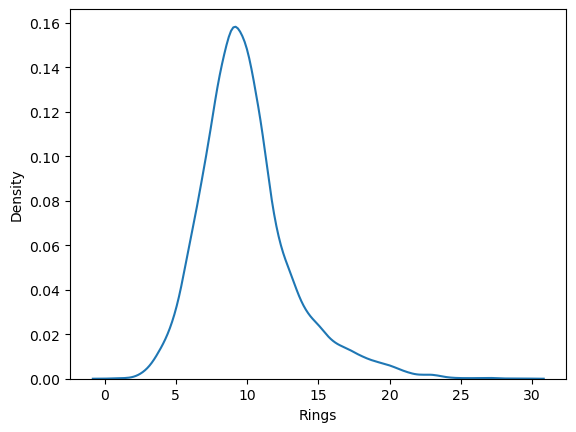

In [30]:
sns.kdeplot(x=df.Rings, data=df)

<Axes: >

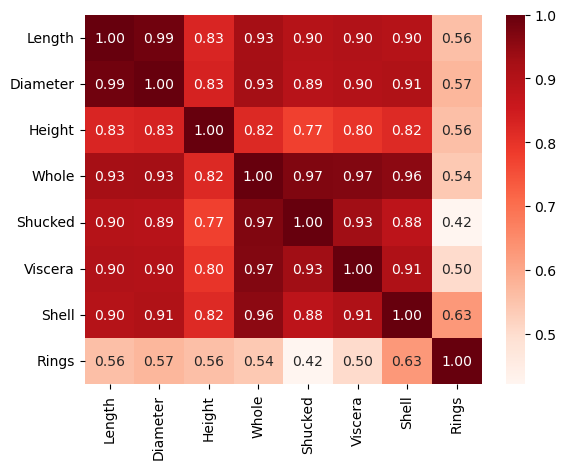

In [33]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Reds", fmt=".2f")

<Axes: xlabel='Shell', ylabel='Rings'>

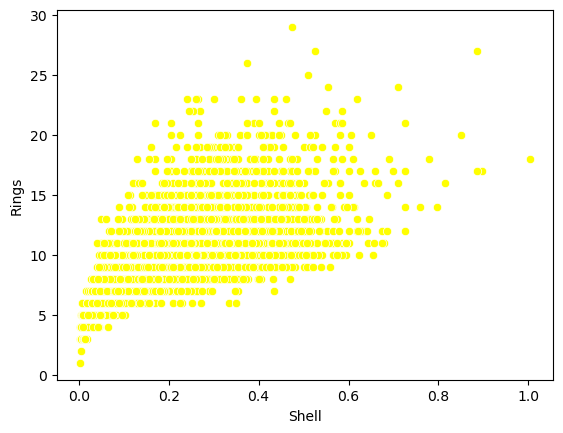

In [34]:
sns.scatterplot(x=df.Shell, y=df.Rings, data=df, color="yellow")

In [35]:
df[df.Height==0]

,Sex,Length,Diameter,Height,Whole,Shucked,Viscera,Shell,Rings
1257,I,0.430,0.34,0.0,0.428,0.2065,0.0860,0.1150,8
3996,I,0.315,0.23,0.0,0.134,0.0575,0.0285,0.3505,6


## 2-vazifa: Dizayn matritsasi X va vektor y
`X = np.c_[np.ones(m), ...]` — birinchi ustun bias uchun 1-lar. `y` — 1D vektor. `X.shape`, `X[:3]` ni chiqaring.

`Height == 0` bo'lgan 2 qator — xato, olib tashlang. `Sex` matnli: `pd.get_dummies(df['Sex'], prefix='Sex', drop_first=True, dtype=float)` → 2 ustun (`Sex_I`, `Sex_M`; `F` — tayanch kategoriya). 7-vazifada uchala ustunli variantni ham sinaysiz.

**Savol 2.** Nega 1-lar ustuni kerak? Uni olib tashlasak θ₀ (intercept) qayerga ketadi va model qanday cheklanadi?

theta uchun 1 lar ustunin qoshish bu bizga biasni qoshish uchun yoziladi. Agar bias, intercept yoq bolsa model (0, 0) nuqta yani koordinatalar boshdan otsihga tog'ri keladi 

In [47]:
df = df[df.Height > 0]
# TODO: Sex → dummies (drop_first=True, dtype=float); X_raw = numeric + dummies; y = df[TARGET].values
# TODO: X (bias ustuni bilan) va y ni yasang

df_encoded = pd.get_dummies(df, columns=["Sex"], drop_first=True, prefix="Sex", dtype=float)

In [48]:
df_encoded.columns.to_list()

['Length',
 'Diameter',
 'Height',
 'Whole',
 'Shucked',
 'Viscera',
 'Shell',
 'Rings',
 'Sex_I',
 'Sex_M']

In [50]:
X = df_encoded.drop(columns=["Rings"])
y = df_encoded["Rings"]

In [52]:
X_b = np.c_[np.ones(len(X)), X]
X_b[:3]

array([[1.    , 0.455 , 0.365 , 0.095 , 0.514 , 0.2245, 0.101 , 0.15  ,
        0.    , 1.    ],
       [1.    , 0.35  , 0.265 , 0.09  , 0.2255, 0.0995, 0.0485, 0.07  ,
        0.    , 1.    ],
       [1.    , 0.53  , 0.42  , 0.135 , 0.677 , 0.2565, 0.1415, 0.21  ,
        0.    , 0.    ]])

## 3-vazifa: Normal Equation
Funksiya yozing va θ ni feature nomlari bilan jadval ko'rinishida chiqaring.

**Savol 3.** Eng katta |θ| qaysi feature'da? Bu "eng muhim feature" degani **emas** — nega? (maslahat: o'lchov birliklari; 8-vazifada qaytamiz)

Eng katta absolut theta bu shucked approximately 19.7, bu degani eng muhim feature degani emas. CHunki hali featurelar scale qilinmagan va hamma feature har xil scaleda boladi shuning uchun hozircha bu eng muhim feature emas.

In [55]:
cols = df_encoded.drop(columns=["Rings"]).columns.tolist()

In [75]:
def normal_equation(X, y):
    """θ = (XᵀX)⁻¹ Xᵀ y — faqat np.linalg"""
    # TODO
    theta = np.linalg.inv(X_b.T@X_b)@X_b.T@y
    return theta
    

theta = normal_equation(X, y)
# TODO: pd.Series(theta, index=['bias'] + feature_nomlari)
theta_series = pd.Series(theta, index=["bias"] + cols)
theta

array([  3.90862753,  -0.43427785,  10.99668705,  10.72197045,
         8.87828261, -19.70107482, -10.50477196,   8.93921764,
        -0.82551034,   0.05757634])

## 4-vazifa: Metrikalar — formuladan
`y_pred = X @ theta`. MSE, RMSE, MAE va R² = 1 − SS_res/SS_tot ni **o'zingiz** yozing (sklearn.metrics ishlatmasdan), keyin `sklearn.metrics` bilan `np.isclose` orqali tekshiring.

**Savol 4.** RMSE ni target o'lchov birligida izohlang ("model o'rtacha … ga adashadi"). R² ning 0 va 1 qiymatlari nimani anglatadi? Manfiy bo'lishi mumkinmi?

r2 bu linear regressionda accuracyni ifodalaydi r2=1 bu perfect model, r2=0 bu mdoel uchun faqat y_mean ni qaytaradi, r2<0 bolishi mumkin bu lekin predictionda meanni ham aniqlay olmaydi, yani this is like trash model

RMSE=2.19 ga adashdi bzning modelimiz abalone predictida 2.2 rings yani yoshga adashdi

In [65]:
def mse(y_true, y_pred): 
    error = y_pred-y_true
    return np.mean(error**2)

    
def r2(y_true, y_pred):   # TODO: 1 - SS_res / SS_tot
    error = y_pred - y_true    
    ss_res = np.sum(error**2)

    y_mean = np.mean(y_true)
    ss_tot = np.sum((y_true-y_mean)**2)

    return 1-ss_res/ss_tot

def mae(y_true, y_pred):
    return np.mean(np.abs(y_pred-y_true))

def rmse(y_true, y_pred):
    error = y_pred-y_true
    return np.sqrt(np.mean(error**2))
    
                   
y_pred = X_b @ theta
# TODO: 4 ta metrika + sklearn bilan tekshirish
mse_val = mse(y, y_pred)
r2_val = r2(y, y_pred)
rmse_val = rmse(y, y_pred)
mae_val = mae(y, y_pred)

print("MSE scratch :", np.round(mse_val, 2))
print("R2 scratch  :", np.round(r2_val, 2))
print("MAE scratch :", np.round(mae_val, 2))
print("RMSE scratch:", np.round(rmse_val, 2))
print()
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score
print("===== Sklearn comparison with isclose()=====")
print(np.isclose(mse_val, mean_squared_error(y, y_pred)))
print(np.isclose(r2_val, r2_score(y, y_pred)))
print(np.isclose(mae_val, mean_absolute_error(y, y_pred)))
print(np.isclose(rmse_val, root_mean_squared_error(y, y_pred)))

MSE scratch : 4.8
R2 scratch  : 0.54
MAE scratch : 1.58
RMSE scratch: 2.19

===== Sklearn comparison with isclose()=====
True
True
True
True


## 5-vazifa: sklearn bilan solishtirish
`LinearRegression().fit(X[:, 1:], y)` → `coef_`, `intercept_` sizning θ bilan `np.allclose(..., atol=1e-6)` bo'lishi kerak.

**Savol 5.** Agar kichik farq bo'lsa — sabab nima? sklearn `LinearRegression` teskari matritsa ishlatmaydi: 🔍 hujjatdan qaysi usul (`scipy.linalg.lstsq`, SVD) ekanini toping va 2 gap bilan yozing (kitob 5-bob).

Linear regression inverse matrix ishlatmaydi chunki:
1. On^3 juda sekin
2. collinear featurelarda fail boladi

shuning uchun Lin Reg defaul holatda SVD(linalg.lstsq) yani single value decompostion ishlatadi, bu judayam yaxshi numerically stable va collinear featurelar bilan ishlaganda fail bolmaydi

In [69]:
# TODO: sklearn LinearRegression bilan solishtirish

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_b[:, 1:], y)

weights = model.coef_
bias = model.intercept_

theta_sk = np.hstack([bias, weights])

print("=== All close with sklearn ===")
print(np.allclose(theta, theta_sk, atol=1e-6))  # atol = absolute tolorance
print("Bias: ", bias)
print("Weights: ", weights)

=== All close with sklearn ===
True
Bias:  3.9086275287233176
Weights:  [ -0.43427785  10.99668705  10.72197045   8.87828261 -19.70107482
 -10.50477196   8.93921764  -0.82551034   0.05757634]


## 6-vazifa: Qo'lda train/test split
`np.random.seed(42); idx = np.random.permutation(m)` → 80% train / 20% test (sklearn `train_test_split` **ishlatmang**). θ ni faqat train dan toping, R² ni train va test da alohida hisoblang.

**Savol 6.** Train R² va test R² qanchalik farq qiladi? Bu overfitting belgisimi? Split ni `seed=0, 1, 2` bilan takrorlang — test R² qanchalik "sakraydi"? Bu nimani anglatadi (kitob 1-bob: Train/Validation/Test)?

overfitting darajasi juda kam chunki bu yerda 50- va 57 orasida aylanayapti shuning uchun buni overfitting deb bolmaydi

In [76]:
# TODO: permutation split, train/test R2, 3 xil seed

m = len(X_b)
train_size = int(m*0.8)

for seed in [0, 1, 2]:
    np.random.seed(seed)
    idx = np.random.permutation(m)

    train_idx = idx[:train_size]
    test_idx = idx[train_size:]

    X_train, y_train = X_b[train_idx], y.iloc[train_idx].values
    X_test, y_test = X_b[test_idx], y.iloc[test_idx].values


    theta_train = np.linalg.inv(X_train.T@X_train)@X_train.T@y_train

    y_train_pred = X_train @ theta_train
    y_test_pred = X_test @ theta_train

    r2_train = r2(y_train, y_train_pred)
    r2_test = r2(y_test, y_test_pred)

    print(f"Seed {seed:4d} | Train R2: {r2_train:.4f} | Test R2: {r2_test:.4f}")

Seed    0 | Train R2: 0.5269 | Test R2: 0.5704
Seed    1 | Train R2: 0.5472 | Test R2: 0.4926
Seed    2 | Train R2: 0.5435 | Test R2: 0.5116


## 7-vazifa: XᵀX ni tekshirish — condition number
`np.linalg.cond(X.T @ X)`, `np.linalg.matrix_rank(X)`, `np.linalg.det(X.T @ X)` ni chiqaring.

**Dummy tuzog'i.** Tajriba uchun uchala dummy (`Sex_F`, `Sex_I`, `Sex_M`) bilan `X_full` yasang (bias ustuni bilan). `np.linalg.matrix_rank(X_full)` ustun sonidan 1 ga kam — nega? Maslahat: `Sex_F + Sex_I + Sex_M` yig'indisi nimaga teng va bu bias ustuni bilan qanday bog'liq? `np.linalg.inv(X_full.T @ X_full)` xato bermaydi, lekin θ ma'nosiz — `cond` ni asosiy X bilan solishtiring: necha marta farq qiladi? Nega bu xavfli (xato yo'q, lekin natija noto'g'ri)? Asosiy modelda `Sex_I` koeffitsiyenti nimani anglatadi ("F ga nisbatan")?

**Savol 7.** 🔍 "ill-conditioned matrix" nima? cond juda katta bo'lsa θ ga qanday xavf bor (2–3 gap, o'z so'zingiz bilan)?

In [ ]:
# TODO: cond, rank, det + dataset-specific tekshiruv



## 8-vazifa: Scaling va θ
Har bir feature ni **qo'lda** standartlashtiring: `(x − mean) / std` (mean/std faqat train dan!). Normal Equation ni qayta yeching. Tekshiring: (a) bashoratlar o'zgarmadi (`np.allclose`), (b) θ o'zgardi, (c) cond kamaydi.

**Savol 8.** θ o'zgardi, bashorat o'zgarmadi — nega? Endi qaysi θ ni "feature muhimligi" sifatida solishtirish mumkin va nima uchun (3-savolga qayting)?

In [ ]:
# TODO: qo'lda standartlash, qayta NE, allclose, cond


## 🔍 Tadqiqot (majburiy — kamida 2 tasi)
1. θ ni 4 usulda toping: `np.linalg.inv`, `np.linalg.solve`, `np.linalg.pinv`, `np.linalg.lstsq`. `%timeit` bilan vaqtini o'lchang, jadval tuzing. Nega amalda `inv` **tavsiya qilinmaydi**?
2. Normal Equation murakkabligi O(n³). `np.random.randn` bilan n = 10, 100, 500, 1000, 2000 feature'li sun'iy X yasab (`m = 5000`), `inv(X.T @ X)` vaqtini o'lchang va grafik chizing. Qaysi n dan boshlab Gradient Descent ma'qulroq? (Kitob 5-bob "Head-to-head" jadvaliga solishtiring.)
3. `Whole` ≈ `Shucked + Viscera + Shell` + chig'anoq ichidagi suv. Korrelyatsiya matritsasini chizing (|r| > 0.95 juftlar nechta?). Faqat `Shell` + `Diameter` + `Sex` bilan model qurib to'liq model bilan solishtiring — R² qancha yo'qoladi, cond qancha yaxshilanadi? "Kam feature, barqaror θ" qachon afzal?

In [ ]:
# TODO: tadqiqot

## ⭐ Bonus (+10)
MSE(θ) = (1/m)‖Xθ − y‖² ni θ bo'yicha differensiallab, ∇MSE = 0 dan Normal Equation ni **markdown/LaTeX** da 4–6 qatorda keltirib chiqaring (kitob 4-bob "gradient qayerdan keladi").

## Topshirish

- Fayl nomi: `student3_P1.ipynb` (shu fayl, to'ldirilgan). `Restart & Run All` qilingan, barcha grafiklar ko'rinib turibdi.
- Oxirgi katak — **Xulosa** (markdown, 6–10 gap): nimani o'rgandingiz, qaysi natija kutilmagan bo'ldi, nimani hali tushunmadingiz.
- Himoya: 5 daqiqa — istalgan katakdagi kodni tushuntirib berasiz.

## Baholash (100 ball + bonus)

| Mezon | Ball |
|---|---|
| 1–8 vazifalar to'liq va to'g'ri | 45 |
| Savollarga tahliliy javoblar (8 ta) | 20 |
| Tadqiqot (2 ta) | 15 |
| Kod tozaligi: funksiyalar, izohlar, xatosiz Run All | 10 |
| Grafiklar (sarlavha, o'qlar, izoh) | 10 |
| ⭐ Bonus | +10 |